In [113]:
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import torch
from torch.utils.data import DataLoader

from neuralhydrology.datasetzoo import get_dataset, lamah
from neuralhydrology.datautils.utils import load_scaler
from neuralhydrology.modelzoo.ealstm import EALSTM
from neuralhydrology.modelzoo.customlstm import CustomLSTM
from neuralhydrology.nh_run import eval_run
from neuralhydrology.utils.config import Config

In [114]:
nse_dict = {}

In [115]:
run_dir_path = Path("/home/wuhlmann/BA/test_runs/runs/test_run_0711_161358")

attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

for phase in ["train", "validation", "test"]:

    metrics_path = run_dir_path / f"{phase}/model_epoch015/{phase}_metrics.csv" 

    metrics = pd.read_table(metrics_path, header=0, sep=",")

    nse_dict[phase] = metrics
        


In [116]:
nse_dict

{'train':      basin       NSE
 0        1  0.727423
 1       10  0.640213
 2      100  0.405596
 3      101  0.528566
 4      102  0.588382
 ..     ...       ...
 667     95  0.779724
 668     96  0.798328
 669     97  0.674565
 670     98  0.564213
 671     99  0.624430
 
 [672 rows x 2 columns],
 'validation':     basin        NSE
 0      12 -10.099487
 1     122   0.784723
 2     125   0.701847
 3     135  -1.715429
 4     137   0.105408
 ..    ...        ...
 79    843  -0.032826
 80    854   0.547610
 81    864   0.327611
 82    880  -0.750406
 83     92  -7.394158
 
 [84 rows x 2 columns],
 'test':     basin       NSE
 0     103  0.608608
 1     120 -0.760566
 2     123  0.494722
 3     131 -0.064765
 4      14  0.156492
 ..    ...       ...
 80    871  0.411659
 81    878  0.441909
 82     89  0.413754
 83      9  0.622813
 84     93  0.640369
 
 [85 rows x 2 columns]}

In [ ]:
phase = "train"

fig, ax = plt.subplots(figsize=(8, 8))

df = nse_dict[phase]

print(f"{phase} NSE median is {df['NSE'].median()}")

sub_0_basins = df[df["NSE"] < 0]

test_basins = basin_stca_gdf.loc[df["basin"].values]
test_basins.plot(ax=ax, color="lightblue", edgecolor="gray")
highlight = basin_stca_gdf.loc[sub_0_basins["basin"].values]
highlight.plot(ax=ax, color="red", edgecolor="black")

train NSE median is 0.5826450884342194


<Axes: >

In [ ]:
sub_0_basins

[array([121, 161, 392, 435,  85]),
 array([ 12, 135, 141, 154, 160, 166, 173, 185, 271, 288, 333, 361, 370,
        401, 498,  54, 561, 697, 784,  79, 843, 880,  92]),
 array([120, 131, 206, 232, 234, 242, 322,  40, 451, 460, 521, 572,  58,
        583, 595, 634, 635, 674, 685, 686, 707, 715, 722, 764, 791, 795,
        804, 845])]

train NSE median is 0.5826450884342194
validation NSE median is 0.41882506012916565
test NSE median is 0.3387447595596313


<Axes: >

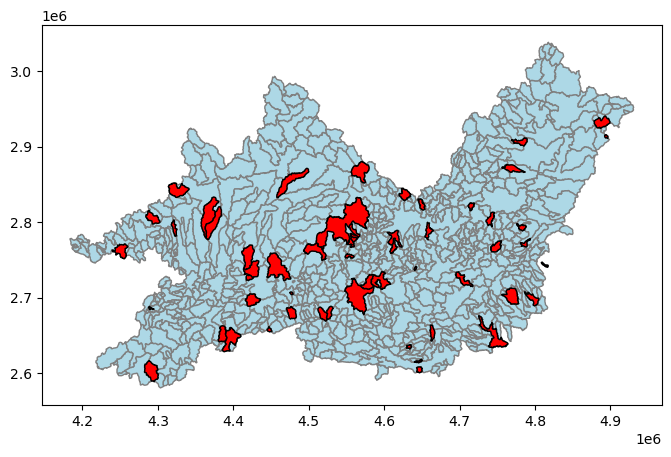

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

sub_0_basins = []

for phase, df in nse_dict.items():

    print(f"{phase} NSE median is {df['NSE'].median()}")

    sub_0_basins.extend(df[df["NSE"]<0]["basin"].values)

basin_stca_gdf.plot(ax=ax, color="lightblue", edgecolor="gray")
highlight = basin_stca_gdf.loc[sub_0_basins]
highlight.plot(ax=ax, color="red", edgecolor="black")

